In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ISLP import load_data
import seaborn as sns
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
carseats = load_data("carseats")

In [3]:
carseats.head(2)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes


In [4]:
carseats.shape

(400, 11)

In [5]:
y = carseats["Sales"]
X = carseats.drop(columns=['Sales'])

In [6]:
X['ShelveLoc'].value_counts()

ShelveLoc
Medium    219
Bad        96
Good       85
Name: count, dtype: int64

In [7]:
X['Urban']= X['Urban'].map({'Yes':1, "No":0})
X['US']= X["US"].map({'Yes':1, 'No':0})
X["ShelveLoc"] = X["ShelveLoc"].map({"Good":0, "Medium":1, "Bad":2})

In [8]:
X.columns

Index(['CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [9]:
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X.drop(columns=['Urban', 'US', 'ShelveLoc']))

scaled_X_df = pd.DataFrame(scaled_X, columns=['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education'])
scaled_X_df["Urban"] = X["Urban"]
scaled_X_df["US"] = X["US"]
scaled_X_df["ShelveLoc"] = X["ShelveLoc"]
scaled_X_df.insert(0,'constant',1)

X_train, X_test, y_train, y_test = train_test_split(scaled_X_df, y, test_size=0.2, random_state=42)

In [10]:
X_train.head()

,constant,CompPrice,Income,Advertising,Population,Price,Age,Education,Urban,US,ShelveLoc
3,1,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,0.038208,1,1,1
18,1,-0.977778,1.479105,-0.998939,0.972607,-2.021182,-0.452564,1.184449,0,1,0
202,1,-0.259544,0.334245,-0.396715,1.006576,0.600709,-0.452564,-1.490113,0,1,2
250,1,0.785161,1.300220,0.506621,1.156040,1.700212,1.154355,0.038208,1,1,0
274,1,0.654573,0.870898,-0.697827,-1.344094,0.135535,-1.194219,-1.108033,1,1,1


In [11]:
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)

y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [12]:
X_train.shape

(320, 11)

## Convert the classification data into the numerical values

In [13]:
from ISLP.models import summarize
regressed_X = X_train[['constant', 'Price', 'Urban', 'US']]
model = sm.OLS(y_train, regressed_X).fit()
summarize(model)

,coef,std err,t,P>|t|
constant,6.7854,0.295,23.018,0.000
Price,-1.2487,0.134,-9.293,0.000
Urban,-0.1090,0.292,-0.373,0.709
US,1.0978,0.278,3.950,0.000


In [14]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     33.19
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           1.12e-18
Time:                        12:19:56   Log-Likelihood:                -730.73
No. Observations:                 320   AIC:                             1469.
Df Residuals:                     316   BIC:                             1485.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
constant       6.7854      0.295     23.018      0.000       6.205       7.365
Price         -1.2487      0.134     -9.293      0.000      -1.513      -0.984
Urban         -0.1090      0.292     -0.373      0.709      -0.684       0.466
US             1.0978      0.278      3.950      0.000       0.551       1.645
==============================================================================
Omnibus:                        0.567   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.753   Jarque-Bera (JB):                0.676
Skew:                          -0.007   Prob(JB):                        0.713
Kurtosis:                       2.775   Cond. No.                         4.20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
dummy_X_train = X_train

In [16]:
dummy_X_train.drop(columns=['Population'], inplace=True)

In [17]:
dummy_X_train.drop(columns=['Education'], inplace=True)

In [18]:
dummy_X_train.drop(columns=['Urban'], inplace=True)

In [19]:
dummy_X_train.drop(columns=['US'], inplace=True)

In [20]:
model1 = sm.OLS(y_train,dummy_X_train).fit()
summarize(model1)

,coef,std err,t,P>|t|
constant,9.9712,0.109,91.419,0.0
CompPrice,1.3661,0.073,18.589,0.0
Income,0.4287,0.058,7.403,0.0
Advertising,0.7642,0.058,13.066,0.0
Price,-2.2502,0.074,-30.302,0.0
Age,-0.7834,0.057,-13.628,0.0
ShelveLoc,-2.4026,0.089,-27.103,0.0


In [21]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     316.8
Date:                Sun, 09 Aug 2026   Prob (F-statistic):          1.03e-129
Time:                        12:19:57   Log-Likelihood:                -461.58
No. Observations:                 320   AIC:                             937.2
Df Residuals:                     313   BIC:                             963.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
constant        9.9712      0.109     91.419      0.000       9.757      10.186
CompPrice       1.3661      0.073     18.589      0.000       1.222       1.511
Income          0.4287      0.058      7.403      0.000       0.315       0.543
Advertising     0.7642      0.058     13.066      0.000       0.649       0.879
Price          -2.2502      0.074    -30.302      0.000      -2.396      -2.104
Age            -0.7834      0.057    -13.628      0.000      -0.897      -0.670
ShelveLoc      -2.4026      0.089    -27.103      0.000      -2.577      -2.228
==============================================================================
Omnibus:                        0.501   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.778   Jarque-Bera (JB):                0.423
Skew:                           0.089   Prob(JB):                        0.809
Kurtosis:                       3.016   Cond. No.                         3.59
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
from statsmodels.stats.anova import anova_lm
anova_lm(model, model1)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,316.0,1803.509431,0.0,NaN,NaN,NaN
1,313.0,335.389894,3.0,1468.119537,456.703699,5.921409e-114


<Axes: >

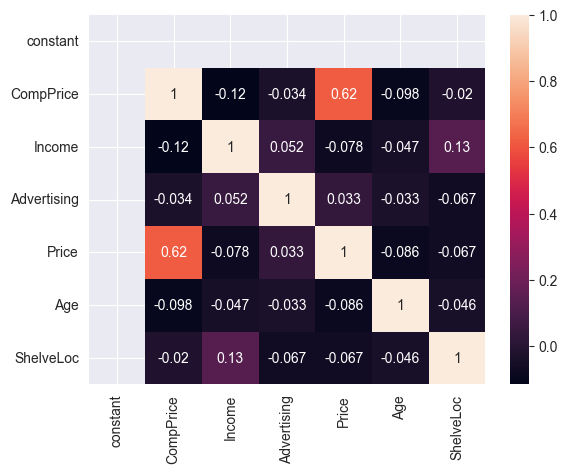

In [22]:
sns.heatmap(dummy_X_train.corr(), annot=True)

In [23]:
dummy_X_train.columns

Index(['constant', 'CompPrice', 'Income', 'Advertising', 'Price', 'Age',
       'ShelveLoc'],
      dtype='object')

In [24]:
X_test.columns

Index(['constant', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'Age', 'Education', 'Urban', 'US', 'ShelveLoc'],
      dtype='object')

In [25]:
dummy_X_test = X_test.drop(columns=['Population', 'Education', 'Urban', 'US'])

In [26]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error
y_pred = model1.predict(dummy_X_test)
print("R2: ", r2_score(y_test, y_pred))
print("MAPE: ", mean_absolute_percentage_error(y_test, y_pred))

R2:  0.8805497333389335
MAPE:  0.1273166185161634


Text(0, 0.5, 'Residuals')

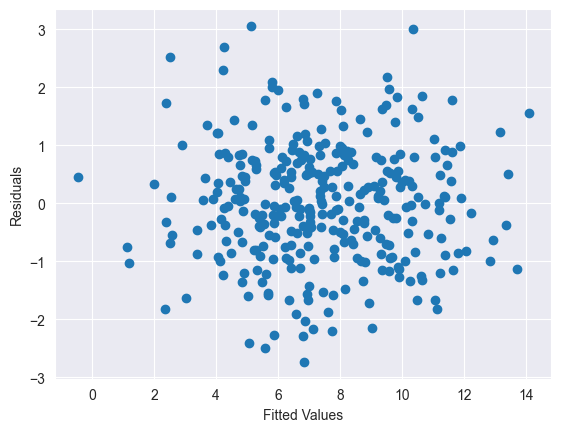

In [27]:
plt.scatter(y=model1.resid, x=model1.fittedvalues)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
vif = [VIF(dummy_X_train,i) for i in range(1,dummy_X_train.shape[1])]
vif = pd.DataFrame(vif, columns=['VIF'], index=dummy_X_train.columns[1:])

In [29]:
vif

,VIF
CompPrice,1.645453
Income,1.037846
Advertising,1.014701
Price,1.634362
Age,1.017461
ShelveLoc,1.030238


In [35]:
dummy_X_train.shape

(320, 7)

In [37]:
average_leverage = (dummy_X_train.shape[1]+1)/dummy_X_train.shape[0]
average_leverage

0.025

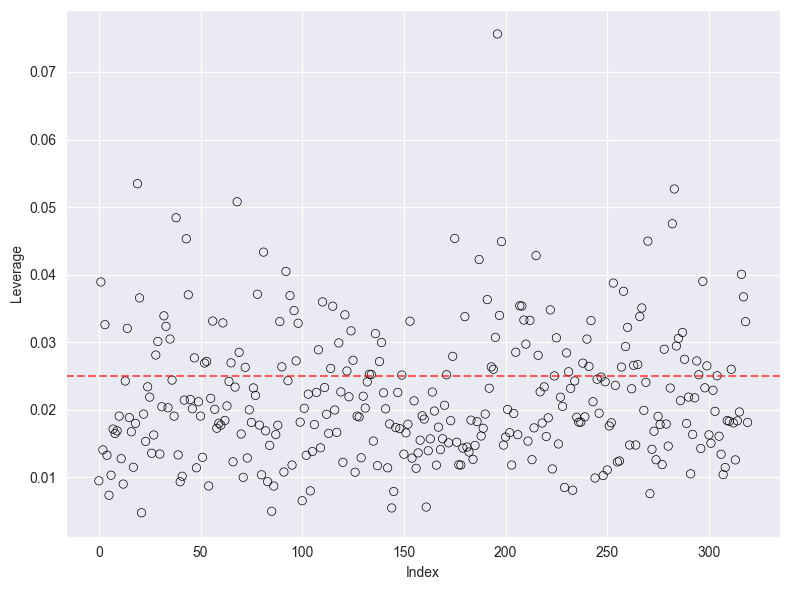

In [45]:
inf = model1.get_influence()
plt.figure(figsize=(8,6))
plt.scatter(y=inf.hat_matrix_diag, x= np.arange(X_train.shape[0]), marker='o', facecolors='none', edgecolors='black', linewidths=0.5)
plt.axhline(average_leverage, ls='--', c='r', alpha=0.6)
plt.xlabel("Index")
plt.ylabel("Leverage")
np.argmax(inf.hat_matrix_diag)
plt.tight_layout()

In [47]:
np.arange(dummy_X_train.shape[0])[inf.hat_matrix_diag/average_leverage > 3]

array([196])

In [54]:
inf.hat_matrix_diag[42]/average_leverage

np.float64(0.8575262173672772)

In [55]:
inf.hat_matrix_diag[42]

np.float64(0.02143815543418193)

In [56]:
dummy_X_train.iloc[42]

constant       1.000000
CompPrice      1.438101
Income         0.191138
Advertising    0.958289
Price          0.642998
Age           -0.081737
ShelveLoc      0.000000
Name: 42, dtype: float64

In [59]:
dummy_X_train["Price"].max(), dummy_X_train["Price"].min()

(np.float64(3.180312128267545), np.float64(-2.8246652298069366))

In [57]:
dummy_X_train.describe()

,constant,CompPrice,Income,Advertising,Price,Age,ShelveLoc
count,320.0,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,1.0,-0.022241,-0.015921,-0.018914,0.013823,-0.000039,1.040625
std,0.0,1.011612,1.019518,0.998248,0.997758,1.016907,0.663589
min,1.0,-2.610130,-1.705035,-0.998939,-2.824665,-1.750460,0.000000
25%,1.0,-0.651308,-0.953721,-0.998939,-0.636232,-0.885196,1.000000
50%,1.0,-0.063662,-0.023523,-0.246159,0.029813,0.103677,1.000000
75%,1.0,0.589279,0.835121,0.807733,0.642998,0.783527,1.000000
max,1.0,3.266335,1.836873,3.367185,3.180312,1.648791,2.000000
